In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("week5_finance_cleaned.csv")
df.head()

,date,open,high,low,close,volume,name,year,month,daily_return,trend,price_change
0,2013-02-08,15.07,15.12,14.63,14.75,8407500.0,AAL,2013,Feb,-0.019661,Loss,-0.32
1,2013-02-11,14.89,15.01,14.26,14.46,8882000.0,AAL,2013,Feb,-0.013140,Loss,-0.43
2,2013-02-12,14.45,14.51,14.10,14.27,8126000.0,AAL,2013,Feb,0.027330,Loss,-0.18
3,2013-02-13,14.30,14.94,14.25,14.66,10259500.0,AAL,2013,Feb,-0.045703,Profit,0.36
4,2013-02-14,14.94,14.96,13.16,13.99,31879900.0,AAL,2013,Feb,0.036455,Loss,-0.95


In [30]:
df['date'] = pd.to_datetime(df['date'])

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619041 entries, 0 to 619040
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          619040 non-null  datetime64[ns]
 1   open          619041 non-null  float64       
 2   high          619041 non-null  float64       
 3   low           619041 non-null  float64       
 4   close         619041 non-null  float64       
 5   volume        619041 non-null  float64       
 6   name          619041 non-null  object        
 7   year          619041 non-null  int64         
 8   month         619041 non-null  object        
 9   daily_return  619041 non-null  float64       
 10  trend         619041 non-null  object        
 11  price_change  619041 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 56.7+ MB


In [32]:
df.describe()

,date,open,high,low,close,volume,year,daily_return,price_change
count,619040,619041.000000,619041.000000,619041.000000,619041.000000,6.190410e+05,619041.000000,619041.000000,619041.000000
mean,2015-08-18 00:48:23.494443264,83.022938,83.778011,82.255802,83.043730,4.321820e+06,2015.125016,0.000541,0.020792
min,2013-02-08 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00,1900.000000,-1.000000,-100.980000
25%,2014-05-20 00:00:00,40.220000,40.620000,39.830000,40.245000,1.070325e+06,2014.000000,-0.006809,-0.370000
50%,2015-08-21 00:00:00,62.590000,63.150000,62.020000,62.620000,2.082094e+06,2015.000000,0.000631,0.020000
75%,2016-11-15 00:00:00,94.370000,95.180000,93.535000,94.410000,4.284507e+06,2016.000000,0.008106,0.420000
max,2018-02-07 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08,2018.000000,19.664360,463.500000
std,NaN,97.377867,98.206836,96.506750,97.389673,8.693603e+06,1.453221,0.046567,1.669260


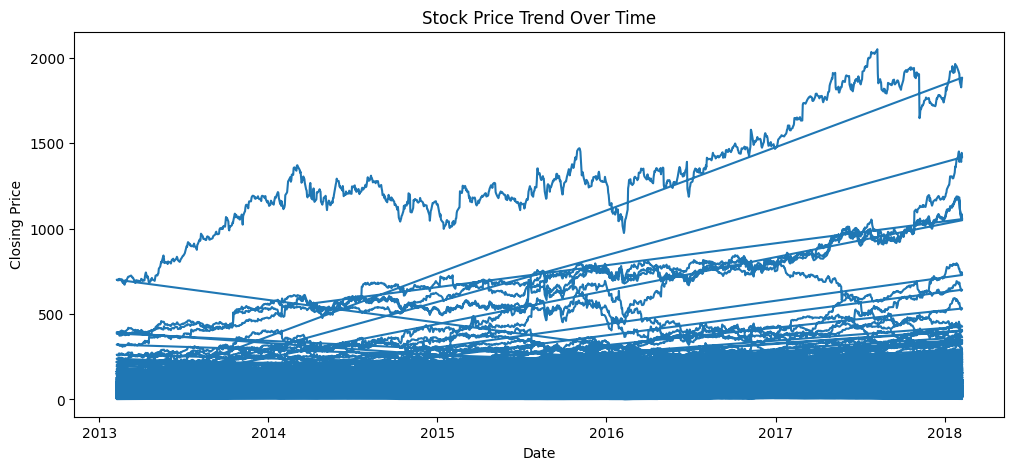

In [33]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['close'])
plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

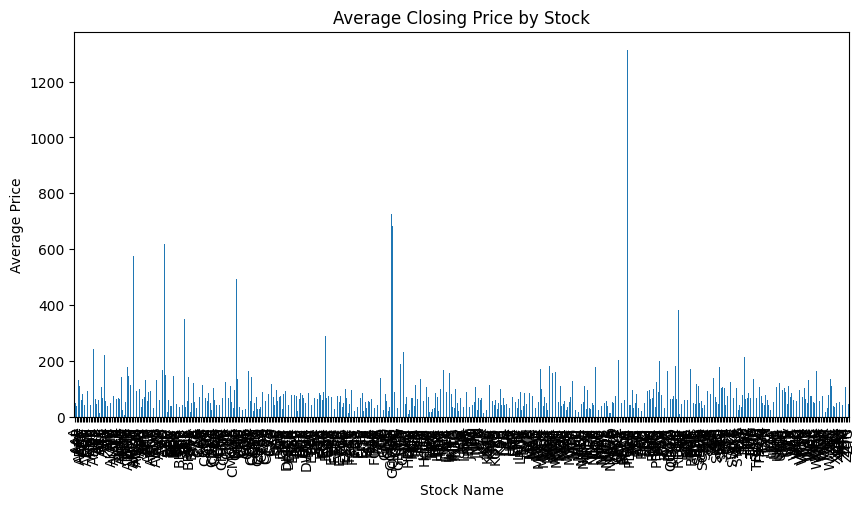

In [34]:
avg_price = df.groupby('name')['close'].mean()
plt.figure(figsize=(10,5))
avg_price.plot(kind='bar')
plt.title("Average Closing Price by Stock")
plt.xlabel("Stock Name")
plt.ylabel("Average Price")
plt.show()

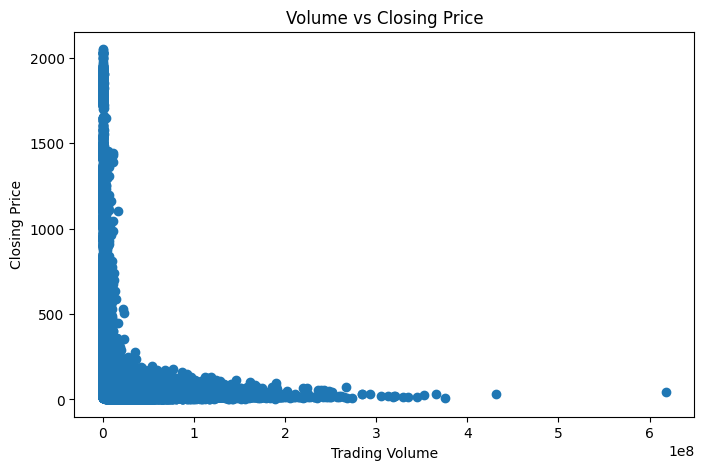

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(df['volume'], df['close'])
plt.title("Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.show()

In [37]:
df['movement'] = df['daily_return'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

In [38]:
df['movement'].value_counts()

,count
movement,
Profit,322596
Loss,296445


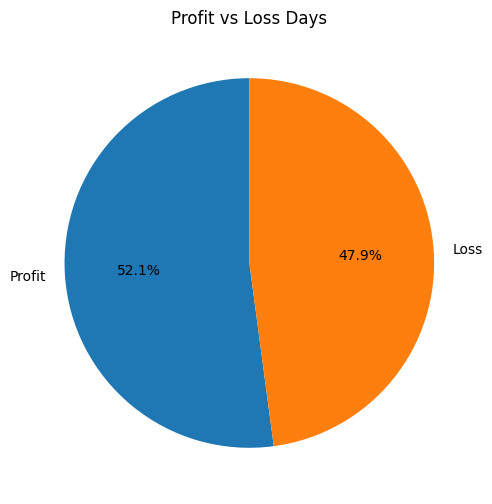

In [39]:
movement_count = df['movement'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    movement_count.values,
    labels=movement_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Profit vs Loss Days")
plt.show()

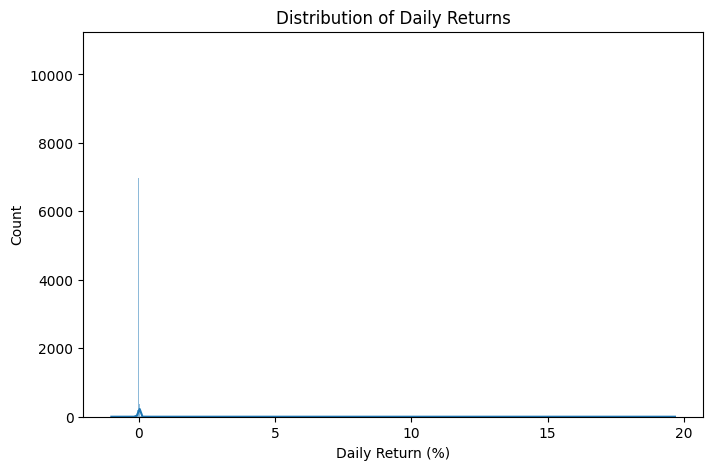

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_return'], kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.show()

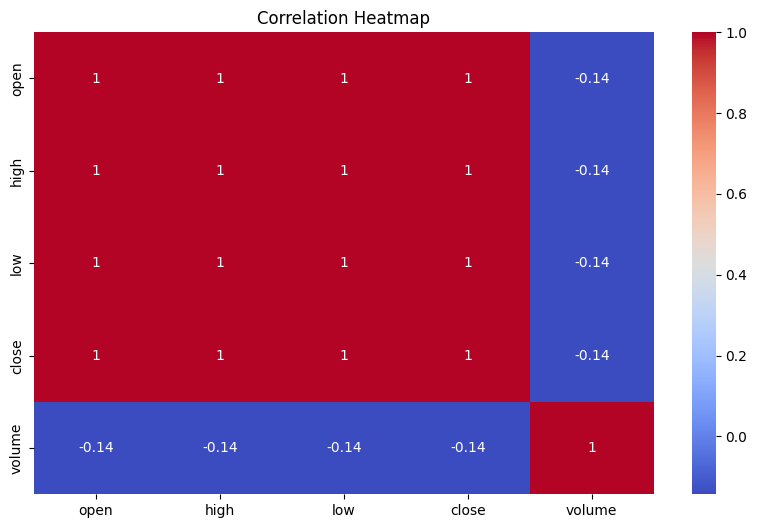

In [41]:
plt.figure(figsize=(10,6))
corr = df[['open','high','low','close','volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

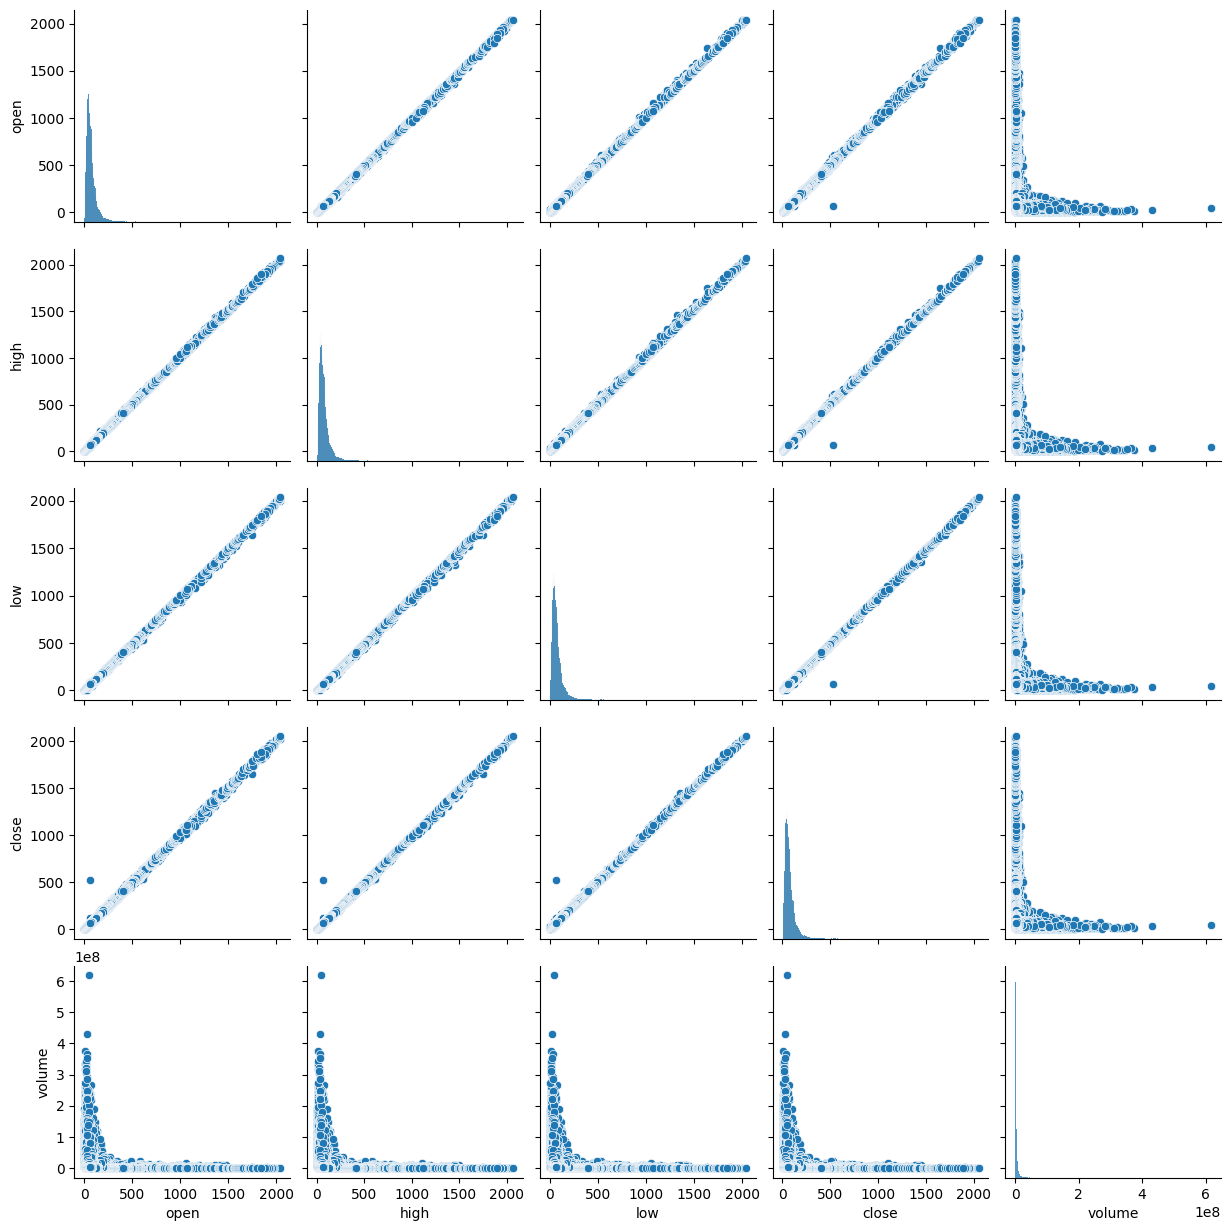

In [42]:
sns.pairplot(df[['open','high','low','close','volume']])
plt.show()

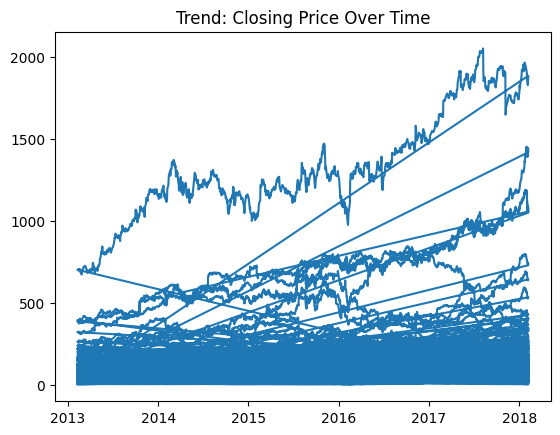

In [43]:
plt.plot(df['date'], df['close'])
plt.title("Trend: Closing Price Over Time")
plt.show()

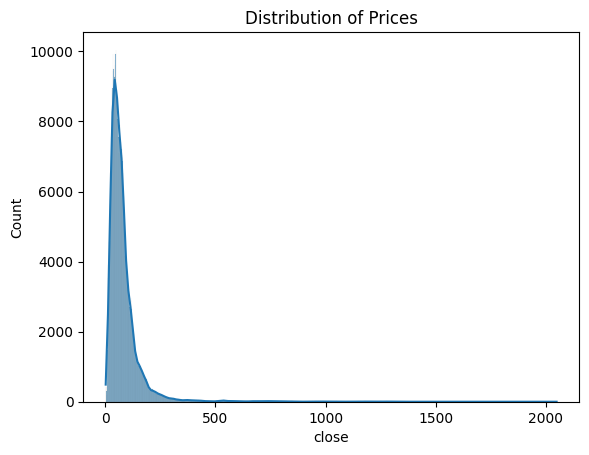

In [44]:
sns.histplot(df['close'], kde=True)
plt.title("Distribution of Prices")
plt.show()

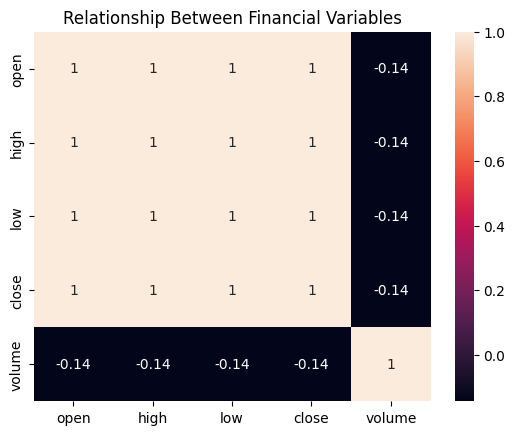

In [45]:
sns.heatmap(corr, annot=True)
plt.title("Relationship Between Financial Variables")
plt.show()